# Single-Seed Multimodal Baseline Agreement

## 1. Objective, hypotheses, and scope

This notebook asks **when raw image+geo concatenation helps, and when it does not**, by comparing instance-level outputs from the final checkpoints of the image-only, geo-only, and raw-concat baselines.

The fixed scope is the cleaned CS test set (1,347 images in 531 plots), seed 1, and the final epoch-50 best_model.pt checkpoints. The hypotheses are that fusion behaviour depends on habitat, on image/geo agreement and complementarity, and on the confidence structure of their output distributions. We also inspect rescues, losses, and false-positive flows for each L3 habitat.

> All probability-derived quantities use the models' native softmax at **T=1**. They are **uncalibrated diagnostics**, not calibrated-confidence claims. Plot-cluster intervals describe uncertainty from the current test sample, not variability across training seeds. Oracle-selected checkpoints and multi-seed comparisons are outside this notebook's scope.


## 2. Single configuration cell

Run this cell first. Set AGREEMENT_CACHE_POLICY=cache_only to guarantee that the notebook uses only the canonical cache and does not access checkpoints. Set AGREEMENT_BOOTSTRAP_REPLICATES to a smaller value for a quick exploratory pass; the report default is 2,000.


In [1]:
from __future__ import annotations

import os
import sys
from argparse import Namespace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "multimodal").is_dir():
    raise RuntimeError("Run this notebook from the repository root or notebooks/ directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from multimodal.agreement import (
    AgreementConfig, analysis_paths, bootstrap_uncertainty,
    build_analysis_tables, derive_per_instance_metrics,
    export_analysis_report, load_or_build_model_outputs,
    validate_artifacts, validate_model_outputs,
)
from multimodal_main import load_configs

ANALYSIS_SEED = 1
JOINED_TABLE_TAG = "gse_100m_cleaned_test"
RUN_TAG = "gse_100m_train_cleaned_test_epoch50"
CACHE_POLICY = os.getenv("AGREEMENT_CACHE_POLICY", "reuse_or_build")
BOOTSTRAP_REPLICATES = int(os.getenv("AGREEMENT_BOOTSTRAP_REPLICATES", "2000"))

cfg = load_configs(Namespace(
    base_config=str(REPO_ROOT / "configs/multimodal_base.yaml"),
    dataset_config=str(REPO_ROOT / "configs/multimodal_cs_geo_100m_cleaned_test.yaml"),
    opts=[
        "seed", str(ANALYSIS_SEED),
        "multimodal.joined_table_tag", JOINED_TABLE_TAG,
        "multimodal.run_tag", RUN_TAG,
        "multimodal.image_feature_source", "habitat_finetuned",
    ],
))
cfg["root_path"] = str(REPO_ROOT)

spec = AgreementConfig(
    seed=ANALYSIS_SEED, joined_table_tag=JOINED_TABLE_TAG, run_tag=RUN_TAG,
    checkpoint_name="best_model.pt",
    device=os.getenv("AGREEMENT_DEVICE", "auto"),
    batch_size=int(os.getenv("AGREEMENT_BATCH_SIZE", "256")),
    cache_policy=CACHE_POLICY, bootstrap_replicates=BOOTSTRAP_REPLICATES,
    bootstrap_seed=20260714,
)
paths = analysis_paths(cfg, spec)

display(pd.Series({
    "seed": spec.seed, "joined_table_tag": spec.joined_table_tag,
    "run_tag": spec.run_tag, "checkpoint": spec.checkpoint_name,
    "cache_policy": spec.cache_policy,
    "bootstrap_replicates": spec.bootstrap_replicates,
    "bootstrap_seed": spec.bootstrap_seed,
    "temperature": 1.0, "calibrated": False,
}, name="analysis configuration"))


seed                                                      1
joined_table_tag                      gse_100m_cleaned_test
run_tag                 gse_100m_train_cleaned_test_epoch50
checkpoint                                    best_model.pt
cache_policy                                 reuse_or_build
bootstrap_replicates                                   2000
bootstrap_seed                                     20260714
temperature                                             1.0
calibrated                                            False
Name: analysis configuration, dtype: object

## 3. Input, checkpoint, and class-map validation

For reuse-or-build and rebuild, this checks the joined split, all three final checkpoints, saved geo scalers, metrics files, feature dimensions, and class mappings before inference. In cache-only mode, checkpoint validation is intentionally skipped. Cache provenance is still validated in the next section.


In [2]:
display(pd.Series({key: str(value) for key, value in paths.items()}, name="resolved paths"))
if spec.cache_policy == "cache_only":
    artifact_validation = {"status": "skipped", "reason": "cache_only never accesses checkpoints"}
    display(pd.Series(artifact_validation, name="artifact validation"))
else:
    artifact_validation = validate_artifacts(cfg, spec)
    display(pd.Series({
        "status": "passed",
        "joined_table_dir": artifact_validation["joined_table_dir"],
        "class_count": len(artifact_validation["class_names"]),
        "class_order": " | ".join(artifact_validation["class_names"]),
    }, name="artifact validation"))
    compact_models = []
    for mode, record in artifact_validation["models"].items():
        compact_models.append({
            "mode": mode, "run_dir": record["run_dir"],
            "checkpoint_sha256": record["fingerprints"]["checkpoint"]["sha256"][:12],
            "scaler_sha256": record["fingerprints"]["scaler"]["sha256"][:12],
            "metrics_sha256": record["fingerprints"]["metrics"]["sha256"][:12],
        })
    display(pd.DataFrame(compact_models))


output_root               /home/hshi/Documents/researchproject/aihab/rep...
analysis_dir              /home/hshi/Documents/researchproject/aihab/rep...
report_dir                /home/hshi/Documents/researchproject/aihab/rep...
model_outputs             /home/hshi/Documents/researchproject/aihab/rep...
model_outputs_manifest    /home/hshi/Documents/researchproject/aihab/rep...
per_instance_metrics      /home/hshi/Documents/researchproject/aihab/rep...
summary_md                /home/hshi/Documents/researchproject/aihab/rep...
summary_json              /home/hshi/Documents/researchproject/aihab/rep...
figures_dir               /home/hshi/Documents/researchproject/aihab/rep...
Name: resolved paths, dtype: object

status                                                         passed
joined_table_dir    /home/hshi/Documents/researchproject/aihab/rep...
class_count                                                        18
class_order         Urban | Broadleaved Mixed and Yew Woodland | C...
Name: artifact validation, dtype: object

,mode,run_dir,checkpoint_sha256,scaler_sha256,metrics_sha256
0,image_only,/home/hshi/Documents/researchproject/aihab/rep...,a0b3339463de,a37dd8c9e53b,07edeb46594e
1,geo_only,/home/hshi/Documents/researchproject/aihab/rep...,23becb43a723,a37dd8c9e53b,53e873a44945
2,raw_concat,/home/hshi/Documents/researchproject/aihab/rep...,846ac6378885,a37dd8c9e53b,1f7b5116385b


## 4. Create or load the canonical model-output cache

Inference and analysis are separate stages. model_outputs.parquet stores logits and native-T=1 probabilities for all three models, keyed by filename and plot. Once the cache and manifest exist, the remainder can run with cache-only and without loading a model.


In [3]:
model_outputs, manifest = load_or_build_model_outputs(cfg, spec)
validate_model_outputs(model_outputs, manifest)
cache_validation = {"status": "passed", "schema_version": manifest.get("schema_version")}
display(pd.Series({
    "rows": len(model_outputs),
    "unique_files": model_outputs["file_normalized"].nunique(),
    "plots": model_outputs["plot_idx"].nunique(),
    "classes": len(manifest["class_names"]),
    "temperature": manifest.get("temperature"),
    "calibrated": manifest.get("calibrated"),
}, name="canonical cache"))
display(pd.json_normalize(cache_validation, sep=".").T.rename(columns={0: "value"}))
display(model_outputs[["row_index", "file", "plot_idx", "label_name",
                       "image_pred", "geo_pred", "fusion_pred"]].head())


rows             1347
unique_files     1347
plots             531
classes            18
temperature       1.0
calibrated      False
Name: canonical cache, dtype: object

,value
status,passed
schema_version,1.0


,row_index,file,plot_idx,label_name,image_pred,geo_pred,fusion_pred
0,0,ATT248_13XX3_2023_photo1-20230510-144821.jpg,13XX3,Improved Grassland,4,4,4
1,1,ATT1012_721XX4_photo4-20190819-113924.jpg,721XX4,Arable and Horticulture,3,3,3
2,2,ATT533_457X5_2021_photo2-20210621-132634.jpg,457X5,Neutral Grassland,5,5,5
3,3,ATT3603_810XX2_2023_photo1-20230919-112145.jpg,810XX2,Broadleaved Mixed and Yew Woodland,1,5,1
4,4,ATT157_494XX3_2022_photo1-20220510-102922.jpg,494XX3,Broadleaved Mixed and Yew Woodland,1,1,1


## 5. Reproduction checks against saved final metrics

The helper validates reconstructed confusion matrices and final top-1, top-3, weighted F1, and MCC against each run's saved metrics. The visible check below guards against accidentally analysing another run. Notebook NLL is a proper sample-weighted mean and is not expected to equal the trainer's batch-mean-averaged test loss.


In [4]:
per_instance = derive_per_instance_metrics(model_outputs, manifest.get("class_names"))
tables = build_analysis_tables(per_instance, manifest)
expected_top1 = {"image": 0.7312546399406088, "geo": 0.6154417223459540,
                 "fusion": 0.7438752783964365}
reproduction = pd.DataFrame([{
    "model": model,
    "recomputed_top1": float(per_instance[f"{model}_correct"].mean()),
    "expected_saved_top1": expected,
    "absolute_difference": abs(float(per_instance[f"{model}_correct"].mean()) - expected),
} for model, expected in expected_top1.items()])
if not np.allclose(reproduction["recomputed_top1"], reproduction["expected_saved_top1"], atol=1e-12):
    raise AssertionError("Recomputed final top-1 does not match the saved seed-1 results.")
display(reproduction.style.format({"recomputed_top1": "{:.6%}",
                                   "expected_saved_top1": "{:.6%}",
                                   "absolute_difference": "{:.2e}"}))
display(pd.json_normalize(manifest.get("reproduction_checks", {}), sep=".").T)
display(tables["overall"])


,model,recomputed_top1,expected_saved_top1,absolute_difference
0,image,73.125464%,73.125464%,0.00e+00
1,geo,61.544172%,61.544172%,0.00e+00
2,fusion,74.387528%,74.387528%,0.00e+00


,0
image_only.saved.top1_acc,0.731255
image_only.saved.top3_acc,0.924276
image_only.saved.f1,0.722877
image_only.saved.mcc,0.694636
image_only.recomputed.top1_acc,0.731255
image_only.recomputed.top3_acc,0.924276
image_only.recomputed.f1,0.722877
image_only.recomputed.mcc,0.694636
image_only.absolute_delta.top1_acc,0.0
image_only.absolute_delta.top3_acc,0.0


,metric,value,numerator,denominator,unit,probability_basis
0,image_accuracy,0.731255,985.0,1347.0,rate,None
1,geo_accuracy,0.615442,829.0,1347.0,rate,None
2,fusion_accuracy,0.743875,1002.0,1347.0,rate,None
3,image_geo_top1_agreement,0.594655,801.0,1347.0,rate,None
4,image_geo_cohen_kappa,0.536045,NaN,1347.0,value,None
5,mean_top3_overlap,0.546647,NaN,1347.0,value,None
6,both_correct_rate,0.515219,694.0,1347.0,rate,None
7,image_exclusive_rate,0.216036,291.0,1347.0,rate,None
8,geo_exclusive_rate,0.100223,135.0,1347.0,rate,None
9,double_fault_rate,0.168523,227.0,1347.0,rate,None


## 6. Overall hard agreement

Top-1 agreement, Cohen's kappa, top-3 overlap, and the image-versus-geo prediction-pair table describe how often the single-modality baselines make the same hard decision. Agreement is not correctness, so read these alongside the next section.


In [5]:
display(tables["overall"])
display(tables["prediction_pair"].head(40))


,metric,value,numerator,denominator,unit,probability_basis
0,image_accuracy,0.731255,985.0,1347.0,rate,None
1,geo_accuracy,0.615442,829.0,1347.0,rate,None
2,fusion_accuracy,0.743875,1002.0,1347.0,rate,None
3,image_geo_top1_agreement,0.594655,801.0,1347.0,rate,None
4,image_geo_cohen_kappa,0.536045,NaN,1347.0,value,None
5,mean_top3_overlap,0.546647,NaN,1347.0,value,None
6,both_correct_rate,0.515219,694.0,1347.0,rate,None
7,image_exclusive_rate,0.216036,291.0,1347.0,rate,None
8,geo_exclusive_rate,0.100223,135.0,1347.0,rate,None
9,double_fault_rate,0.168523,227.0,1347.0,rate,None


,image_pred,geo_pred,count,rate,image_pred_name,geo_pred_name
0,0,0,0,0.000000,Urban,Urban
1,0,1,0,0.000000,Urban,Broadleaved Mixed and Yew Woodland
2,0,2,0,0.000000,Urban,Coniferous Woodland
3,0,3,0,0.000000,Urban,Arable and Horticulture
4,0,4,0,0.000000,Urban,Improved Grassland
5,0,5,0,0.000000,Urban,Neutral Grassland
6,0,6,0,0.000000,Urban,Calcareous Grassland
7,0,7,0,0.000000,Urban,Acid Grassland
8,0,8,0,0.000000,Urban,Bracken
9,0,9,0,0.000000,Urban,Dwarf Shrub Heath


## 7. Correctness complementarity and routing-oracle opportunity

The four mutually exclusive states are both correct, image-exclusive correct, geo-exclusive correct, and neither correct. Double fault is the neither state; routing-oracle accuracy is the fraction where at least one single modality is correct. Same-wrong and different-wrong cases separate shared blind spots from divergent errors.


In [6]:
display(tables["correctness_state"])


,state,count,rate
0,both_correct,694,0.515219
1,image_only_correct,291,0.216036
2,geo_only_correct,135,0.100223
3,neither_correct,227,0.168523


## 8. Fusion preservation, capture, synergy, and negative transfer

This measures whether fusion preserves consensus, captures image- or geo-exclusive correct cases, solves cases where both baselines fail, misses the routing-oracle opportunity, or turns a correct single-modality decision into an error. It also records whether fusion selects the image class, geo class, or a third class when the baselines disagree. Undefined conditional rates are NA.


In [7]:
display(tables["fusion_capture"])


,metric,value,numerator,denominator
0,consensus_preservation,0.988764,792,801
1,image_exclusive_capture,0.948454,276,291
2,geo_exclusive_capture,0.170370,23,135
3,synergy_rate,0.012621,17,1347
4,conditional_synergy,0.074890,17,227
5,missed_oracle_rate,0.100223,135,1347
6,conditional_negative_transfer,0.120536,135,1120
7,selects_image_when_baselines_disagree,0.860806,470,546
8,selects_geo_when_baselines_disagree,0.082418,45,546
9,selects_third_class_when_baselines_disagree,0.056777,31,546


## 9. Native-T=1 soft diagnostics

Normalized Jensen-Shannon divergence and total-variation distance quantify image/geo distributional disagreement. Confidence, normalized entropy, top-two margin, and signed geo-minus-image NLL describe decisiveness and which modality gives the true class more probability. These values are uncalibrated.


,group,metric,probability_basis,count,mean,std,q05,median,q95
0,overall,image_geo_jsd_native_t1,native_t1_uncalibrated,1347,0.315700,0.342294,0.000191,0.162299,0.968596
1,overall,image_geo_tv_native_t1,native_t1_uncalibrated,1347,0.405640,0.377052,0.000357,0.300670,0.992731
2,overall,geo_minus_image_true_class_nll_native_t1,native_t1_uncalibrated,1347,-0.200560,3.613522,-7.848348,0.026917,4.965047
3,overall,image_confidence_t1,native_t1_uncalibrated,1347,0.943604,0.121532,0.637889,0.999530,0.999999
4,overall,geo_confidence_t1,native_t1_uncalibrated,1347,0.816945,0.191572,0.450939,0.897562,0.999741
...,...,...,...,...,...,...,...,...,...
79,fusion_wrong,geo_entropy_normalized_t1,native_t1_uncalibrated,345,0.209586,0.139855,0.017714,0.210355,0.471795
80,fusion_wrong,fusion_entropy_normalized_t1,native_t1_uncalibrated,345,0.114232,0.126870,0.000041,0.057452,0.367595
81,fusion_wrong,image_top2_margin_t1,native_t1_uncalibrated,345,0.792230,0.273143,0.205488,0.946511,0.999968
82,fusion_wrong,geo_top2_margin_t1,native_t1_uncalibrated,345,0.608863,0.322263,0.052814,0.690717,0.987364


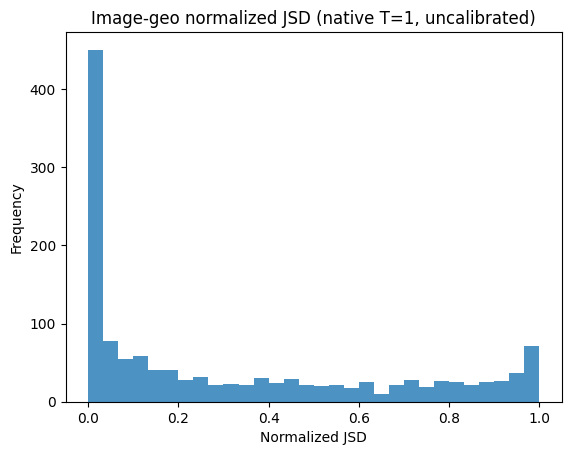

In [8]:
display(tables["soft_diagnostic"])
jsd_columns = [c for c in per_instance.columns if "jsd" in c.lower() and "image" in c.lower() and "geo" in c.lower()]
if len(jsd_columns) != 1:
    raise RuntimeError(f"Expected one image-geo JSD column, found {jsd_columns}")
ax = per_instance[jsd_columns[0]].plot.hist(
    bins=30, alpha=0.8, title="Image-geo normalized JSD (native T=1, uncalibrated)")
ax.set_xlabel("Normalized JSD")
plt.show()


## 10. Per-habitat agreement and fusion behaviour

Per-habitat results retain the overall definitions. Habitats with fewer than 20 images or 10 plots are marked low support, and zero-support or undefined quantities remain NA rather than being converted to zero.


In [9]:
per_habitat = tables["per_habitat"].copy()
display(per_habitat)


,class_index,label_name,support,plots,low_support,image_precision,image_recall,image_f1,image_tp,image_fp,...,image_mean_top2_margin_native_t1,image_mean_true_class_nll_native_t1,geo_mean_confidence_native_t1,geo_mean_entropy_normalized_native_t1,geo_mean_top2_margin_native_t1,geo_mean_true_class_nll_native_t1,fusion_mean_confidence_native_t1,fusion_mean_entropy_normalized_native_t1,fusion_mean_top2_margin_native_t1,fusion_mean_true_class_nll_native_t1
0,0,Urban,2,1,True,NaN,0.000000,0.000000,0,0,...,0.793315,6.510017,0.820649,0.184526,0.656696,5.881156,0.735666,0.196236,0.475386,5.524325
1,1,Broadleaved Mixed and Yew Woodland,92,39,False,0.865979,0.913043,0.888889,84,13,...,0.957239,0.416096,0.828667,0.163254,0.705489,1.916743,0.957972,0.032938,0.922085,0.317513
2,2,Coniferous Woodland,88,39,False,0.873418,0.784091,0.826347,69,10,...,0.942286,0.918888,0.791719,0.183003,0.653232,0.985675,0.948904,0.045050,0.902230,0.709142
3,3,Arable and Horticulture,230,99,False,0.921811,0.973913,0.947146,224,19,...,0.986262,0.131604,0.933900,0.063888,0.885686,0.350139,0.992225,0.007494,0.985803,0.067483
4,4,Improved Grassland,229,91,False,0.733333,0.720524,0.726872,165,60,...,0.876992,1.575597,0.742985,0.214281,0.544144,1.292898,0.933606,0.056716,0.873942,1.638560
5,5,Neutral Grassland,174,67,False,0.581006,0.597701,0.589235,104,75,...,0.881262,3.196930,0.719543,0.235745,0.512756,1.599617,0.927468,0.065283,0.870678,3.122689
6,6,Calcareous Grassland,8,4,True,0.000000,0.000000,0.000000,0,1,...,0.810110,7.398656,0.743964,0.248356,0.604667,5.514016,0.882102,0.093820,0.796389,5.566847
7,7,Acid Grassland,130,48,False,0.591241,0.623077,0.606742,81,56,...,0.835136,2.315585,0.788735,0.188753,0.626278,1.759212,0.933757,0.067561,0.876985,2.164317
8,8,Bracken,26,9,True,0.461538,0.461538,0.461538,12,14,...,0.785165,2.069199,0.790798,0.203652,0.647388,2.817596,0.883234,0.095128,0.792695,1.749186
9,9,Dwarf Shrub Heath,121,44,False,0.615385,0.661157,0.637450,80,50,...,0.858971,1.823709,0.835490,0.168275,0.740319,1.901703,0.923249,0.072688,0.862064,1.946206


## 11. Per-habitat F1 and TP/FP-flow decomposition

F1 changes are decomposed into true positives rescued or lost and false positives introduced or removed. Comparisons are separate against image-only and geo-only because fusion can improve on one modality while trailing the other.


In [10]:
display(Markdown("### Fusion versus image-only"))
display(tables["f1_flow_vs_image"])
display(Markdown("### Fusion versus geo-only"))
display(tables["f1_flow_vs_geo"])


### Fusion versus image-only

,class_index,label_name,support,baseline,baseline_precision,baseline_recall,baseline_f1,fusion_precision,fusion_recall,fusion_f1,...,baseline_tp,fusion_tp,baseline_fp,fusion_fp,tp_rescued,tp_lost,fp_introduced,fp_removed,tp_delta,fp_delta
0,0,Urban,2,image,NaN,0.000000,0.000000,NaN,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,1,Broadleaved Mixed and Yew Woodland,92,image,0.865979,0.913043,0.888889,0.896907,0.945652,0.920635,...,84,87,13,10,3,0,1,4,3,-3
2,2,Coniferous Woodland,88,image,0.873418,0.784091,0.826347,0.880952,0.840909,0.860465,...,69,74,10,10,7,2,3,3,5,0
3,3,Arable and Horticulture,230,image,0.921811,0.973913,0.947146,0.922449,0.982609,0.951579,...,224,226,19,19,3,1,0,0,2,0
4,4,Improved Grassland,229,image,0.733333,0.720524,0.726872,0.752294,0.716157,0.733781,...,165,164,60,54,5,6,2,8,-1,-6
5,5,Neutral Grassland,174,image,0.581006,0.597701,0.589235,0.571429,0.620690,0.595041,...,104,108,75,81,7,3,9,3,4,6
6,6,Calcareous Grassland,8,image,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,...,0,0,1,0,0,0,0,1,0,-1
7,7,Acid Grassland,130,image,0.591241,0.623077,0.606742,0.565517,0.630769,0.596364,...,81,82,56,63,2,1,12,5,1,7
8,8,Bracken,26,image,0.461538,0.461538,0.461538,0.800000,0.461538,0.585366,...,12,12,14,3,1,1,0,11,0,-11
9,9,Dwarf Shrub Heath,121,image,0.615385,0.661157,0.637450,0.663793,0.636364,0.649789,...,80,77,50,39,2,5,2,13,-3,-11


### Fusion versus geo-only

,class_index,label_name,support,baseline,baseline_precision,baseline_recall,baseline_f1,fusion_precision,fusion_recall,fusion_f1,...,baseline_tp,fusion_tp,baseline_fp,fusion_fp,tp_rescued,tp_lost,fp_introduced,fp_removed,tp_delta,fp_delta
0,0,Urban,2,geo,NaN,0.000000,0.000000,NaN,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,1,Broadleaved Mixed and Yew Woodland,92,geo,0.500000,0.456522,0.477273,0.896907,0.945652,0.920635,...,42,87,42,10,45,0,9,41,45,-32
2,2,Coniferous Woodland,88,geo,0.813953,0.795455,0.804598,0.880952,0.840909,0.860465,...,70,74,16,10,17,13,3,9,4,-6
3,3,Arable and Horticulture,230,geo,0.817829,0.917391,0.864754,0.922449,0.982609,0.951579,...,211,226,47,19,17,2,14,42,15,-28
4,4,Improved Grassland,229,geo,0.600000,0.510917,0.551887,0.752294,0.716157,0.733781,...,117,164,78,54,69,22,29,53,47,-24
5,5,Neutral Grassland,174,geo,0.411504,0.534483,0.465000,0.571429,0.620690,0.595041,...,93,108,133,81,44,29,48,100,15,-52
6,6,Calcareous Grassland,8,geo,NaN,0.000000,0.000000,NaN,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
7,7,Acid Grassland,130,geo,0.548148,0.569231,0.558491,0.565517,0.630769,0.596364,...,74,82,61,63,27,19,51,49,8,2
8,8,Bracken,26,geo,0.529412,0.346154,0.418605,0.800000,0.461538,0.585366,...,9,12,8,3,7,4,2,7,3,-5
9,9,Dwarf Shrub Heath,121,geo,0.577586,0.553719,0.565401,0.663793,0.636364,0.649789,...,67,77,49,39,19,9,23,33,10,-10


## 12. Ranked failure and rescue cases

The priority table ranks fusion rescues, missed-oracle cases, conditional negative transfers, and high image-geo disagreement. The montage is optional and disabled by default so table/report execution does not depend on image decoding.


In [11]:
priority_samples = tables["priority_sample"]
display(priority_samples.head(40))

SHOW_IMAGE_MONTAGE = False
MONTAGE_ROWS = 12
if SHOW_IMAGE_MONTAGE:
    from PIL import Image as PILImage
    sample = priority_samples.head(MONTAGE_ROWS)
    ncols, nrows = 4, int(np.ceil(len(sample) / 4))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, sample.iterrows()):
        source_dir = Path(str(row["image_source"]))
        if not source_dir.is_absolute():
            source_dir = REPO_ROOT / source_dir
        ax.imshow(PILImage.open(source_dir / str(row["file"])).convert("RGB"))
        ax.set_title(f"{row['label_name']}\n{row['file']}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    fig.suptitle("Priority fusion cases")
    fig.tight_layout()
    plt.show()


,category,rank_within_category,row_index,file,file_normalized,plot_idx,label_name,image_source,class_index,image_pred,...,geo_pred,geo_pred_name,fusion_pred,fusion_pred_name,image_geo_correctness_state,image_geo_jsd_native_t1,image_geo_tv_native_t1,image_nll_t1,geo_nll_t1,fusion_nll_t1
0,synergy_rescue,1,576,ATT52_632XX2_2020_photo3-20200806-093637.jpg,att52_632xx2_2020_photo3-20200806-093637.jpg,632XX2,Improved Grassland,./data/CS_Xplots_2019_2023_test,4,11,...,5,Neutral Grassland,4,Improved Grassland,neither_correct,0.992957,0.998451,6.579711,1.063749,7.295658e-02
1,synergy_rescue,2,556,ATT348_1118X2_2021_photo1-20210605-100657.jpg,att348_1118x2_2021_photo1-20210605-100657.jpg,1118X2,Bracken,./data/CS_Xplots_2019_2023_test,8,4,...,11,Bog,8,Bracken,neither_correct,0.984745,0.995653,2.339676,5.841007,1.896350e-02
2,synergy_rescue,3,398,ATT279_1215XX3_2020_photo2-20200824-143536.jpg,att279_1215xx3_2020_photo2-20200824-143536.jpg,1215XX3,Inland Rock,./data/CS_Xplots_2019_2023_test,15,17,...,7,Acid Grassland,15,Inland Rock,neither_correct,0.934467,0.980526,1.144475,5.746702,3.367226e-01
3,synergy_rescue,4,571,ATT2843_1216X2_2023_photo1-20230801-124532.jpg,att2843_1216x2_2023_photo1-20230801-124532.jpg,1216X2,Broadleaved Mixed and Yew Woodland,./data/CS_Xplots_2019_2023_test,1,2,...,3,Arable and Horticulture,1,Broadleaved Mixed and Yew Woodland,neither_correct,0.919485,0.936685,2.392621,2.775779,4.465246e-01
4,synergy_rescue,5,283,ATT2844_1216X2_2023_photo2-20230801-124550.jpg,att2844_1216x2_2023_photo2-20230801-124550.jpg,1216X2,Broadleaved Mixed and Yew Woodland,./data/CS_Xplots_2019_2023_test,1,2,...,3,Arable and Horticulture,1,Broadleaved Mixed and Yew Woodland,neither_correct,0.914086,0.936679,2.237536,2.775779,3.634877e-01
5,synergy_rescue,6,693,ATT281_1215XX3_2020_photo4-20200824-143820.jpg,att281_1215xx3_2020_photo4-20200824-143820.jpg,1215XX3,Inland Rock,./data/CS_Xplots_2019_2023_test,15,17,...,7,Acid Grassland,15,Inland Rock,neither_correct,0.887462,0.960913,2.957574,5.746702,9.376044e-01
6,synergy_rescue,7,756,ATT3610_810XX4_2023_photo3-20230919-141416.jpg,att3610_810xx4_2023_photo3-20230919-141416.jpg,810XX4,Improved Grassland,./data/CS_Xplots_2019_2023_test,4,7,...,5,Neutral Grassland,4,Improved Grassland,neither_correct,0.881361,0.951622,3.228936,1.416425,2.423998e-02
7,synergy_rescue,8,1055,ATT280_1215XX3_2020_photo3-20200824-143902.jpg,att280_1215xx3_2020_photo3-20200824-143902.jpg,1215XX3,Inland Rock,./data/CS_Xplots_2019_2023_test,15,17,...,7,Acid Grassland,15,Inland Rock,neither_correct,0.834149,0.929007,3.198767,5.746702,8.115039e-01
8,synergy_rescue,9,288,ATT661_1125X4_2022_photo1-20220628-111545.jpg,att661_1125x4_2022_photo1-20220628-111545.jpg,1125X4,Inland Rock,./data/CS_Xplots_2019_2023_test,15,9,...,11,Bog,15,Inland Rock,neither_correct,0.806612,0.916188,1.102678,2.848615,5.170628e-01
9,synergy_rescue,10,168,ATT3612_810XX1_2023_photo1-20230919-163941.jpg,att3612_810xx1_2023_photo1-20230919-163941.jpg,810XX1,Broadleaved Mixed and Yew Woodland,./data/CS_Xplots_2019_2023_test,1,4,...,5,Neutral Grassland,1,Broadleaved Mixed and Yew Woodland,neither_correct,0.723982,0.850640,2.355954,2.609996,6.041481e-01


## 13. Paired habitat-stratified plot-cluster bootstrap

Complete plot groups are resampled within ground-truth habitats, with identical replicates for all models. The default is 2,000 replicates with seed 20260714. A conditional interval is reported only when at least 95% of replicates have a valid denominator.


In [ ]:
bootstrap = bootstrap_uncertainty(
    per_instance, manifest.get("class_names"),
    n_replicates=spec.bootstrap_replicates, seed=spec.bootstrap_seed,
    min_valid_fraction=0.95,
)
display(bootstrap)
display(Markdown("*These intervals measure plot-cluster uncertainty in this cleaned test set; "
                 "they do not measure training-seed variability.*"))


## 14. Export intermediate metrics, tables, figures, and report

This writes per-instance native-T=1 metrics, summary Markdown/JSON, all requested CSV tables, and diagnostic figures under the analysis/report directories. Generated artifacts remain ignored by Git; the notebook and helper are tracked sources.


In [ ]:
exports = export_analysis_report(
    per_instance, tables, bootstrap, manifest, spec, cfg=cfg,
)
display(pd.Series({key: str(value) for key, value in exports.items()}, name="exported artifacts"))
summary_path = exports.get("summary_markdown") or exports.get("summary_md")
if summary_path is not None:
    display(Markdown(f"Report written to: {summary_path}"))
